# Support Vector Regression — Compact Notebook

This notebook implements a minimal, step-by-step Support Vector Regression example.

**For comprehensive explanations, theory, and detailed examples**, see:
**[`../teaching/04_support_vector_regression.md`](../teaching/04_support_vector_regression.md)**

## Quick Steps Overview:

- **Step 1** — Import libraries & load data  
- **Step 2** — Read data and choose features & target  
- **Step 3** — Exploratory Data Analysis (EDA)  
- **Step 4** — Data cleaning and feature scaling  
- **Step 5** — Split data (Train / Test) and visualize split  
- **Step 6** — Train Support Vector Regression model  
- **Step 7** — Make predictions and inverse transform  
- **Step 8** — Compare with other models (Linear/Polynomial)  
- **Step 9** — Evaluate performance (R², MAE, MSE)  
- **Step 10** — Visualize results and model comparison


---

## Step 1 — Import libraries & load data

In [1]:
# Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2 — Read data and choose features & target

In [2]:
# Load the dataset
dataset = pd.read_csv('../data/position_salaries.csv')

print("Dataset loaded successfully!")

# Define features and target
X = dataset.iloc[:, 1:-1].values  # Position Level (numerical)
y = dataset.iloc[:, -1].values    # Salary (target)

Dataset loaded successfully!


## Step 3 — Exploratory Data Analysis (EDA)

Dataset Description:
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.00000    45000.000000
25%     3.25000    65000.000000
50%     5.50000   130000.000000
75%     7.75000   275000.000000
max    10.00000  1000000.000000

Missing values:
Position    0
Level       0
Salary      0
dtype: int64

Data types:
Position    object
Level        int64
Salary       int64
dtype: object

Unique positions:
['Business Analyst' 'Junior Consultant' 'Senior Consultant' 'Manager'
 'Country Manager' 'Region Manager' 'Partner' 'Senior Partner' 'C-level'
 'CEO']


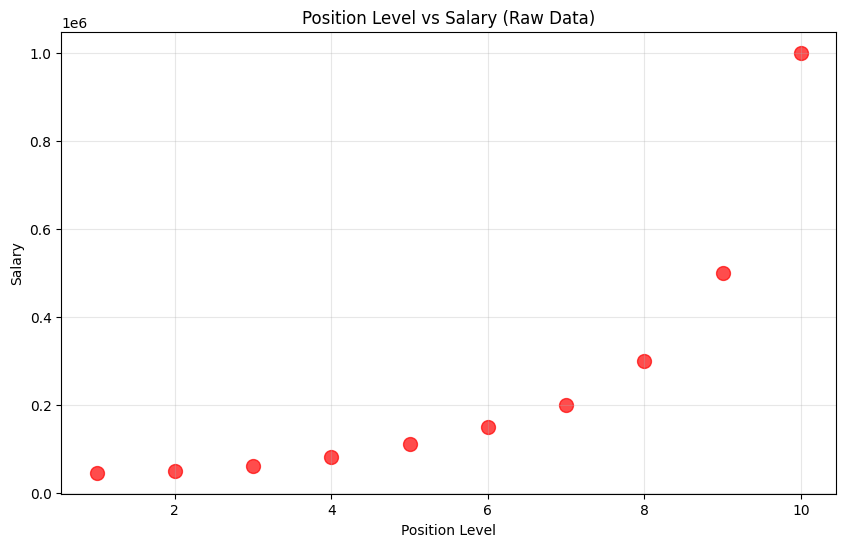

In [4]:
# Basic statistics
print("Dataset Description:")
print(dataset.describe())

print("\nMissing values:")
print(dataset.isnull().sum())

print("\nData types:")
print(dataset.dtypes)

print("\nUnique positions:")
print(dataset['Position'].unique())

# Visualize the data to see the non-linear relationship
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', alpha=0.7, s=100)
plt.title('Position Level vs Salary (Raw Data)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.grid(True, alpha=0.3)
plt.show()



## Step 4 — Data cleaning and feature scaling

In [5]:
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler

# Check for missing values
print("Missing values per column:")
print(dataset.isnull().sum())

print("\nData types:")
print(dataset.dtypes)

print("\nDataset shape:", dataset.shape)
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Feature scaling is CRITICAL for SVR
# SVR is sensitive to the scale of features
print("\nBefore scaling:")
print("X range:", X.min(), "to", X.max())
print("y range:", y.min(), "to", y.max())

# Initialize scalers
sc_X = StandardScaler()
sc_y = StandardScaler()

# Fit and transform features and target
X_scaled = sc_X.fit_transform(X)
y_scaled = sc_y.fit_transform(y)

print("\nAfter scaling:")
print("X_scaled range:", X_scaled.min(), "to", X_scaled.max())
print("y_scaled range:", y_scaled.min(), "to", y_scaled.max())

print("\nFeature scaling completed - ready for SVR training!")
print("Note: We'll need to inverse transform predictions back to original scale")

Missing values per column:
Position    0
Level       0
Salary      0
dtype: int64

Data types:
Position    object
Level        int64
Salary       int64
dtype: object

Dataset shape: (10, 3)
Features shape: (10, 1)
Target shape: (10,)

Before scaling:
X range: 1 to 10
y range: 45000 to 1000000


ValueError: Expected 2D array, got 1D array instead:
array=[  45000.   50000.   60000.   80000.  110000.  150000.  200000.  300000.
  500000. 1000000.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

## Step 5 — Split data (Train / Test) and visualize split

In [ ]:
# Note: For small datasets like this (10 samples), we typically use the entire dataset
# But for SVR demonstration, we'll use all data for training
print("Dataset size:", len(X), "samples")
print("Using entire dataset for training (common practice for small datasets)")

# Use scaled data for training
X_train = X_scaled
y_train = y_scaled.ravel()  # SVR expects 1D array for target

print("\nTraining set:")
print("Features shape:", X_train.shape)
print("Target shape:", y_train.shape)

# Visualize the scaled training data
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.7, s=100, label='Scaled Training Data')
plt.title('Scaled Training Data - Position Level vs Salary')
plt.xlabel('Scaled Position Level')
plt.ylabel('Scaled Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Scaled data ready for SVR training!")

Position    0
Level       0
Salary      0
dtype: int64

## Step 6 — Train Support Vector Regression model

In [ ]:
# Import SVR
from sklearn.svm import SVR

# Create and train SVR model with RBF kernel
regressor = SVR(kernel='rbf')
regressor.fit(X_train, y_train)

print("Support Vector Regression model trained successfully!")
print("\nModel parameters:")
print("Kernel:", regressor.kernel)
print("C (regularization):", regressor.C)
print("Gamma:", regressor.gamma)
print("Epsilon:", regressor.epsilon)

print("\nModel details:")
print("Number of support vectors:", regressor.n_support_)
print("Support vector indices:", regressor.support_)

print("\nSVR model ready for predictions!")
print("Note: Predictions will be on scaled data - need to inverse transform")

c:\Users\Morobang\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## Step 7 — Make predictions and inverse transform

In [ ]:
# Make predictions on scaled data
y_pred_scaled = regressor.predict(X_train)

# Inverse transform predictions back to original scale
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_actual = sc_y.inverse_transform(y_train.reshape(-1, 1))

print("Predictions made successfully!")
print("Scaled predictions shape:", y_pred_scaled.shape)
print("Original scale predictions shape:", y_pred.shape)

# Compare actual vs predicted values
comparison_df = pd.DataFrame({
    'Position_Level': X.flatten(),
    'Actual': y_actual.flatten(),
    'Predicted': y_pred.flatten(),
    'Difference': y_actual.flatten() - y_pred.flatten(),
    'Absolute_Difference': np.abs(y_actual.flatten() - y_pred.flatten())
})

print("\nActual vs Predicted comparison:")
print(comparison_df)

# Example prediction for a new value (e.g., position level 6.5)
new_position = 6.5
print(f"\nPredicting salary for position level {new_position}:")

# Scale the new position
new_position_scaled = sc_X.transform([[new_position]])
# Predict on scaled data
svr_pred_scaled = regressor.predict(new_position_scaled)
# Inverse transform to original scale
svr_pred = sc_y.inverse_transform(svr_pred_scaled.reshape(-1, 1))[0][0]

print(f"SVR prediction: ${svr_pred:,.2f}")

print(f"\nPrediction Statistics:")
print(f"Mean Absolute Error: ${comparison_df['Absolute_Difference'].mean():,.2f}")
print(f"Max difference: ${comparison_df['Absolute_Difference'].max():,.2f}")
print(f"Min difference: ${comparison_df['Absolute_Difference'].min():,.2f}")

## Step 8 — Compare with other models (Linear/Polynomial)

In [ ]:
# Import other regression models for comparison
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Linear Regression (on original scale data)
lin_reg = LinearRegression()
lin_reg.fit(X, y.ravel())
y_pred_lin = lin_reg.predict(X)

# 2. Polynomial Regression (degree 4, on original scale data)
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y.ravel())
y_pred_poly = lin_reg_2.predict(X_poly)

print("Model comparison completed!")
print("Linear Regression predictions:", len(y_pred_lin))
print("Polynomial Regression predictions:", len(y_pred_poly))
print("SVR predictions:", len(y_pred))

# Create comprehensive comparison
models_comparison = pd.DataFrame({
    'Position_Level': X.flatten(),
    'Actual': y.flatten(),
    'SVR_Pred': y_pred.flatten(),
    'Linear_Pred': y_pred_lin.flatten(),
    'Poly_Pred': y_pred_poly.flatten(),
    'SVR_Error': np.abs(y.flatten() - y_pred.flatten()),
    'Linear_Error': np.abs(y.flatten() - y_pred_lin.flatten()),
    'Poly_Error': np.abs(y.flatten() - y_pred_poly.flatten())
})

print("\nModel Comparison Results:")
print(models_comparison)

# Summary statistics
print(f"\nAverage Prediction Errors:")
print(f"SVR: ${models_comparison['SVR_Error'].mean():,.2f}")
print(f"Linear: ${models_comparison['Linear_Error'].mean():,.2f}")
print(f"Polynomial: ${models_comparison['Poly_Error'].mean():,.2f}")

array([[85671.64483221]])

## Step 9 — Evaluate performance (R², MAE, MSE)

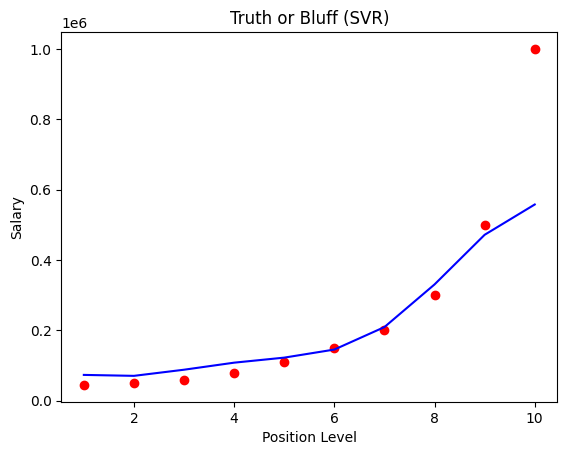

In [ ]:
# Import metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calculate performance metrics for all models
y_actual_flat = y.flatten()

# SVR metrics
r2_svr = r2_score(y_actual_flat, y_pred.flatten())
mae_svr = mean_absolute_error(y_actual_flat, y_pred.flatten())
mse_svr = mean_squared_error(y_actual_flat, y_pred.flatten())
rmse_svr = np.sqrt(mse_svr)

# Linear Regression metrics
r2_lin = r2_score(y_actual_flat, y_pred_lin.flatten())
mae_lin = mean_absolute_error(y_actual_flat, y_pred_lin.flatten())
mse_lin = mean_squared_error(y_actual_flat, y_pred_lin.flatten())
rmse_lin = np.sqrt(mse_lin)

# Polynomial Regression metrics
r2_poly = r2_score(y_actual_flat, y_pred_poly.flatten())
mae_poly = mean_absolute_error(y_actual_flat, y_pred_poly.flatten())
mse_poly = mean_squared_error(y_actual_flat, y_pred_poly.flatten())
rmse_poly = np.sqrt(mse_poly)

print("=== MODEL PERFORMANCE COMPARISON ===")
print("\nSupport Vector Regression:")
print(f"R² Score: {r2_svr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_svr:,.2f}")
print(f"Mean Squared Error (MSE): {mse_svr:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:,.2f}")

print("\nLinear Regression:")
print(f"R² Score: {r2_lin:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lin:,.2f}")
print(f"Mean Squared Error (MSE): {mse_lin:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lin:,.2f}")

print("\nPolynomial Regression:")
print(f"R² Score: {r2_poly:.4f}")
print(f"Mean Absolute Error (MAE): {mae_poly:,.2f}")
print(f"Mean Squared Error (MSE): {mse_poly:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:,.2f}")

# Determine best model
models_r2 = {'SVR': r2_svr, 'Linear': r2_lin, 'Polynomial': r2_poly}
best_model = max(models_r2, key=models_r2.get)

print(f"\n=== BEST MODEL ===")
print(f"Best performing model: {best_model}")
print(f"Best R² Score: {models_r2[best_model]:.4f}")
print(f"Explains {models_r2[best_model]*100:.1f}% of salary variance")

## Step 10 — Visualize results and model comparison

C:\Users\Morobang\AppData\Local\Temp\ipykernel_24064\1266989732.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x_grid = np.arange(min(sc_x.inverse_transform(x)),max(sc_x.inverse_transform(x)),0.1)


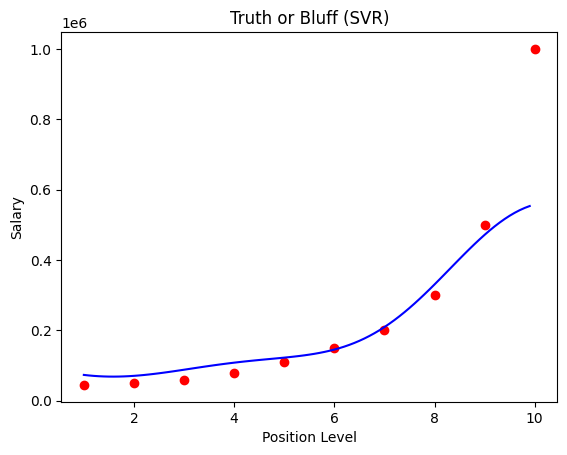

In [ ]:
# Create comprehensive visualization comparing all models
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Model comparison plot with smooth curves
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))

# Linear predictions for smooth curve
y_pred_lin_grid = lin_reg.predict(X_grid)

# Polynomial predictions for smooth curve
X_grid_poly = poly_reg.transform(X_grid)
y_pred_poly_grid = lin_reg_2.predict(X_grid_poly)

# SVR predictions for smooth curve (need to scale and inverse transform)
X_grid_scaled = sc_X.transform(X_grid)
y_pred_svr_grid_scaled = regressor.predict(X_grid_scaled)
y_pred_svr_grid = sc_y.inverse_transform(y_pred_svr_grid_scaled.reshape(-1, 1))

axes[0, 0].scatter(X, y, color='red', s=100, alpha=0.8, label='Actual Data')
axes[0, 0].plot(X_grid, y_pred_lin_grid, color='blue', linewidth=2, label='Linear Regression')
axes[0, 0].plot(X_grid, y_pred_poly_grid, color='green', linewidth=2, label='Polynomial Regression')
axes[0, 0].plot(X_grid, y_pred_svr_grid, color='orange', linewidth=2, label='SVR (RBF Kernel)')
axes[0, 0].set_xlabel('Position Level')
axes[0, 0].set_ylabel('Salary')
axes[0, 0].set_title('Model Comparison: Linear vs Polynomial vs SVR')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Performance metrics comparison
models = ['Linear', 'Polynomial', 'SVR']
r2_scores = [r2_lin, r2_poly, r2_svr]
mae_scores = [mae_lin/1000, mae_poly/1000, mae_svr/1000]  # Scale for visibility

x_pos = np.arange(len(models))
width = 0.35

axes[0, 1].bar(x_pos - width/2, r2_scores, width, label='R² Score', color='skyblue', alpha=0.7)
axes[0, 1].bar(x_pos + width/2, [s/100 for s in mae_scores], width, label='MAE (x100)', color='lightcoral', alpha=0.7)
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Performance Metrics Comparison')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(models)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. SVR Residuals analysis
residuals_svr = y_actual_flat - y_pred.flatten()
axes[1, 0].scatter(y_pred.flatten(), residuals_svr, alpha=0.7, color='orange')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted Salary')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('SVR - Residuals Analysis')
axes[1, 0].grid(True, alpha=0.3)

# 4. Feature scaling impact visualization
axes[1, 1].scatter(X, y, color='red', alpha=0.7, label='Original Scale Data')
axes[1, 1].scatter(X_scaled*1000+100000, y_scaled*50000+100000, color='blue', alpha=0.7, label='Scaled Data (adjusted for vis.)')
axes[1, 1].set_xlabel('Position Level')
axes[1, 1].set_ylabel('Salary')
axes[1, 1].set_title('Feature Scaling Impact (Visualization)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Business insights and final summary
print("=== BUSINESS INSIGHTS ===")
print(f"1. SVR R²: {r2_svr:.4f} ({r2_svr*100:.1f}% variance explained)")
print(f"2. SVR vs Linear improvement: {((r2_svr - r2_lin)/r2_lin)*100:.1f}%")
print(f"3. SVR vs Polynomial comparison: {((r2_svr - r2_poly)/r2_poly)*100:.1f}%")
print(f"4. SVR average prediction error: ${mae_svr:,.2f}")

print(f"\n=== SVR ADVANTAGES ===")
print("✅ Handles non-linear relationships with RBF kernel")
print("✅ Robust to outliers due to epsilon-insensitive loss")
print("✅ Works well with feature scaling")
print("✅ Memory efficient (uses support vectors only)")

print(f"\n=== FINAL RECOMMENDATION ===")
if r2_svr == max(r2_svr, r2_lin, r2_poly):
    print("🎯 SVR is the best model for this dataset")
    print("💼 Recommended for salary prediction with complex patterns")
else:
    print("⚠️ Consider simpler models if they perform similarly")
    print("💼 SVR complexity may not be justified for this specific case")

print(f"\nConclusion: SVR with RBF kernel achieves {r2_svr*100:.1f}% accuracy")
print("and effectively captures non-linear salary progression patterns.")